<a href="https://colab.research.google.com/github/Prince-Srivastava/Simple-CNN-Project/blob/main/Hand_written_alphabet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


In [ ]:
transform = transforms.ToTensor()

train_data = MNIST(root = "data", train = True, download = True, transform = transform)
test_data = MNIST(root = "data", train = False, download = True, transform = transform)

train_loader = DataLoader(train_data, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_data, batch_size = 64, shuffle = False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.2MB/s]


In [ ]:
class SimpleCNN(nn.Module):
  def __init__(self):
      super().__init__()

      self.feature = nn.Sequential(
          nn.Conv2d(1,8,kernel_size = 3, stride = 1, padding = 1),
          nn.ReLU(),
          nn.MaxPool2d(2),

          nn.Conv2d(8,16,kernel_size = 3, padding = 1),
          nn.ReLU(),
          nn.MaxPool2d(2)
      )
      self.classifier = nn.Sequential(
          nn.Linear(16*7*7, 64),
          nn.ReLU(),
          nn.Linear(64,10)
      )

  def forward(self, x):
         x = self.feature(x)
         x = x.view(x.size(0), -1)
         x = self.classifier(x)
         return x

model = SimpleCNN().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

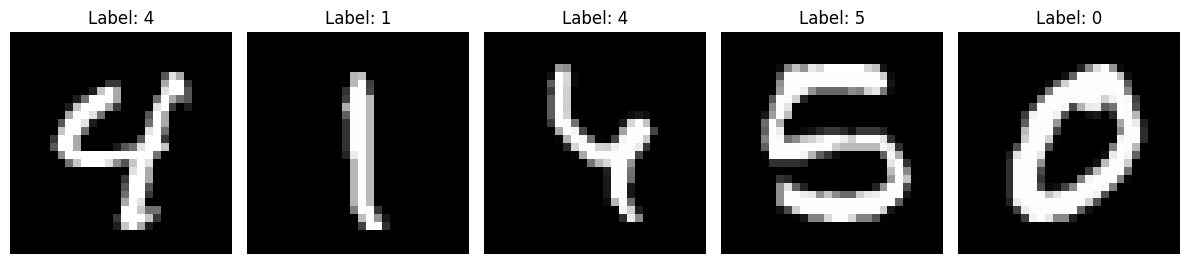

In [ ]:



images, labels = next(iter(train_loader))


fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    ax = axes[i]

    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
epochs = 3;

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = loss_fn(outputs, labels)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss:.4f}")
model.eval()
correct = 0
total = 0

with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    predictions = torch.argmax(outputs, dim = 1)

    correct += (predictions == labels).sum().item()
    total += labels.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy * 100:.2f}%")

torch.save(model.state_dict(), "simple_cnn.pth")
print("Model saved")

Epoch 1/3, Loss: 315.8710
Epoch 2/3, Loss: 91.9816
Epoch 3/3, Loss: 64.9988
Test Accuracy: 97.95%
Model saved
